# XGBoost Classifier for Customer Churn Prediction

## Objective

The objective of this notebook is to develop an XGBoost classifier for customer churn prediction and compare its performance with the previously developed Logistic Regression, Decision Tree and Random Forest models.

XGBoost (Extreme Gradient Boosting) is one of the most powerful machine learning algorithms for structured tabular datasets. Unlike Random Forest, which builds trees independently, XGBoost builds trees sequentially, where each new tree attempts to correct the errors made by the previous trees.

This notebook includes:

- Baseline XGBoost Model
- Cross Validation
- Overfitting Diagnosis
- Hyperparameter Tuning
- Model Evaluation
- Feature Importance
- Comparison with Previous Models
- Model Serialization

In [1]:
import warnings
warnings.filterwarnings("ignore")

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn import set_config

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    OrdinalEncoder
)

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    GridSearchCV
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

from xgboost import XGBClassifier

set_config(display="diagram")

## Load Feature Engineered Dataset

The feature engineered dataset created in Notebook 03 is used for training the XGBoost model.

In [2]:
df = pd.read_csv("../data/processed/telco_feature_engineered.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_Binary,AvgMonthlySpend,TotalServices,HasFamily,TenureGroup,SpendingGroup
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,Electronic check,29.85,29.85,No,0,29.850000,1,0,New,Low
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Mailed check,56.95,1889.50,No,0,55.573529,3,0,Established,Medium
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,Mailed check,53.85,108.15,Yes,1,54.075000,3,0,New,Medium
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Bank transfer (automatic),42.30,1840.75,No,0,40.905556,3,0,Established,Low
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,Electronic check,70.70,151.65,Yes,1,75.825000,1,0,New,Medium


In [3]:
X = df.drop(
    columns=[
        "customerID",
        "Churn",
        "Churn_Binary"
    ]
)

y = df["Churn_Binary"]

print(X.shape)
print(y.shape)

(7032, 24)
(7032,)


In [4]:
continuous_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "AvgMonthlySpend",
    "TotalServices"
]

binary_features = [
    "SeniorCitizen",
    "HasFamily"
]

nominal_features = [
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]

ordinal_features = [
    "TenureGroup",
    "SpendingGroup"
]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [6]:
preprocessor = ColumnTransformer(
    transformers=[

        (
            "continuous",
            "passthrough",
            continuous_features
        ),

        (
            "binary",
            "passthrough",
            binary_features
        ),

        (
            "nominal",
            OneHotEncoder(handle_unknown="ignore"),
            nominal_features
        ),

        (
            "ordinal",
            OrdinalEncoder(
                categories=[
                    ["New","Growing","Established","Loyal"],
                    ["Low","Medium","High"]
                ]
            ),
            ordinal_features
        )

    ]
)

## Baseline XGBoost Model

A baseline XGBoost classifier is trained using the default hyperparameters.

This serves as the initial benchmark before hyperparameter optimization.

In [7]:
baseline_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

In [8]:
pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", baseline_model)
    ]
)

In [9]:
pipeline.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](24,)","['gender','SeniorCitizen','Partner',...,'HasFamily','TenureGroup', 'SpendingGroup']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,24
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('continuous', ...), ('binary', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying `

In [10]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [11]:
metrics = [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc"
]

cv_results = {}

for metric in metrics:

    scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=metric,
        n_jobs=-1
    )

    cv_results[metric] = scores

In [12]:
cv_summary = pd.DataFrame({
    "Metric": metrics,
    "Mean": [cv_results[m].mean() for m in metrics],
    "Std": [cv_results[m].std() for m in metrics]
})

cv_summary["Metric"] = cv_summary["Metric"].str.upper()

cv_summary = cv_summary.round(4)

cv_summary

,Metric,Mean,Std
0,ACCURACY,0.7876,0.0103
1,PRECISION,0.6196,0.0204
2,RECALL,0.5184,0.0315
3,F1,0.5643,0.0266
4,ROC_AUC,0.8293,0.0060


In [13]:
train_pred = pipeline.predict(X_train)

test_pred = pipeline.predict(X_test)

comparison = pd.DataFrame({
    "Dataset":[
        "Training",
        "Testing"
    ],
    "Accuracy":[
        accuracy_score(y_train,train_pred),
        accuracy_score(y_test,test_pred)
    ]
})

comparison

,Dataset,Accuracy
0,Training,0.957867
1,Testing,0.772566


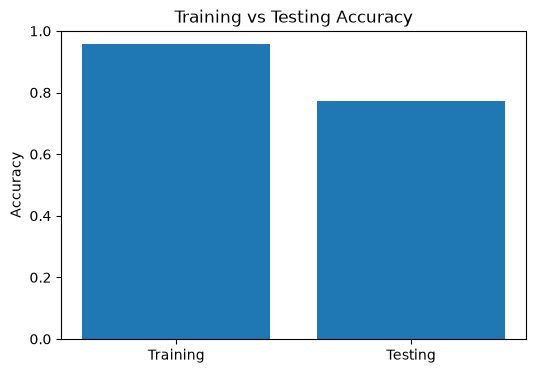

In [14]:
plt.figure(figsize=(6,4))

plt.bar(
    comparison["Dataset"],
    comparison["Accuracy"]
)

plt.ylim(0,1)

plt.ylabel("Accuracy")

plt.title("Training vs Testing Accuracy")

plt.show()

In [15]:
param_grid = {

    "classifier__n_estimators":[
        100,
        200,
        300
    ],

    "classifier__learning_rate":[
        0.01,
        0.05,
        0.1
    ],

    "classifier__max_depth":[
        3,
        5,
        7
    ],

    "classifier__subsample":[
        0.8,
        1.0
    ],

    "classifier__colsample_bytree":[
        0.8,
        1.0
    ]

}

In [16]:
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

In [17]:
grid_search.fit(
    X_train,
    y_train
)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__colsample_bytree': [0.8, 1.0], 'classifier__learning_rate': [0.01, 0.05, ...], 'classifier__max_depth': [3, 5, ...], 'classifier__n_estimators': [100, 200, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... 

In [18]:
print("Best Parameters")
print(grid_search.best_params_)

print()

print("Best ROC-AUC")
print(grid_search.best_score_)

Best Parameters
{'classifier__colsample_bytree': 0.8, 'classifier__learning_rate': 0.05, 'classifier__max_depth': 3, 'classifier__n_estimators': 100, 'classifier__subsample': 1.0}

Best ROC-AUC
0.8480977754743415


## Hyperparameter Tuning Results

GridSearchCV identified the optimal hyperparameter combination using 5-fold Stratified Cross Validation with ROC-AUC as the optimization metric.

The selected configuration balances model complexity and predictive performance while reducing the risk of overfitting.

A relatively shallow tree depth (`max_depth = 3`) together with a smaller learning rate (`learning_rate = 0.05`) indicates that the model favors gradual learning and better generalization instead of memorizing the training data.

The tuned model obtained the highest cross-validation ROC-AUC among all models developed so far, making it the strongest candidate for final evaluation.

## Final XGBoost Model

The tuned XGBoost model obtained from GridSearchCV is selected as the final model.

This model contains the optimal hyperparameters identified during cross validation and will be evaluated on the unseen test dataset.

In [20]:
best_pipeline = grid_search.best_estimator_

## Predictions

Predictions and prediction probabilities are generated using the tuned XGBoost model.

The predicted class labels are used for classification metrics, while the predicted probabilities are used for ROC-AUC evaluation.

In [21]:
y_pred = best_pipeline.predict(X_test)

y_prob = best_pipeline.predict_proba(X_test)[:, 1]

## Model Evaluation

The performance of the tuned XGBoost classifier is evaluated using multiple classification metrics.

The evaluation includes:

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC

Using multiple metrics provides a comprehensive assessment of predictive performance.

In [22]:
test_results = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1-Score": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_prob)
}

test_summary = pd.DataFrame(
    test_results.items(),
    columns=["Metric", "Score"]
)

test_summary["Score"] = test_summary["Score"].round(4)

test_summary

,Metric,Score
0,Accuracy,0.7967
1,Precision,0.6477
2,Recall,0.5160
3,F1-Score,0.5744
4,ROC-AUC,0.8411


## Classification Report

The classification report summarizes the predictive performance for both churn and non-churn customers.

It provides Precision, Recall and F1-Score for each class together with macro and weighted averages.

In [23]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1033
           1       0.65      0.52      0.57       374

    accuracy                           0.80      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg       0.79      0.80      0.79      1407



## Confusion Matrix

The confusion matrix illustrates the number of correctly and incorrectly classified customers.

It provides insight into false positives and false negatives, which are particularly important for customer retention strategies.

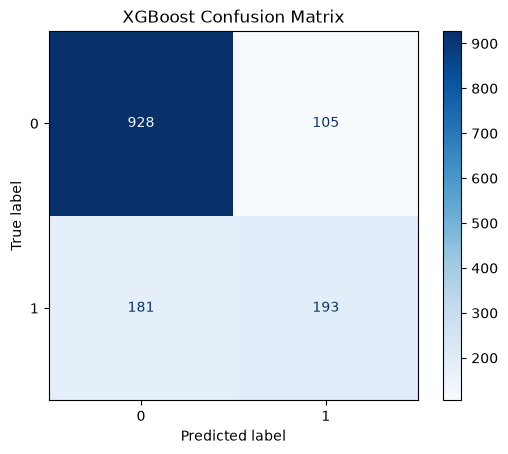

In [24]:
cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(
    confusion_matrix=cm
).plot(cmap="Blues")

plt.title("XGBoost Confusion Matrix")

plt.show()

## ROC Curve

The Receiver Operating Characteristic (ROC) Curve evaluates the model across different classification thresholds.

A larger Area Under the Curve (ROC-AUC) indicates better discrimination between churn and non-churn customers.

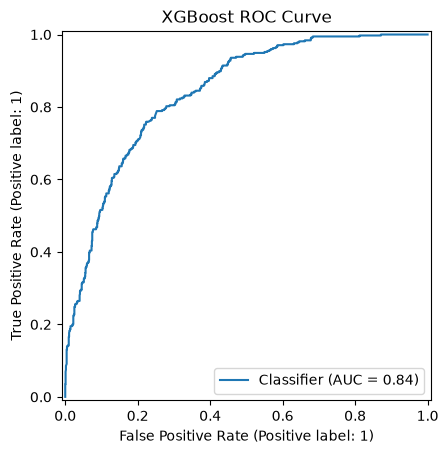

In [25]:
RocCurveDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title("XGBoost ROC Curve")

plt.show()

## Feature Importance

XGBoost estimates the contribution of each feature toward the final prediction.

Higher importance values indicate features that played a greater role in reducing prediction error during tree construction.

Understanding feature importance helps identify the key business drivers of customer churn.

In [26]:
feature_names = best_pipeline.named_steps[
    "preprocessor"
].get_feature_names_out()

importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": best_pipeline.named_steps[
        "classifier"
    ].feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(20)

,Feature,Importance
39,nominal__Contract_Month-to-month,0.380025
21,nominal__OnlineSecurity_No,0.101983
19,nominal__InternetService_Fiber optic,0.084942
30,nominal__TechSupport_No,0.050653
48,ordinal__TenureGroup,0.040284
0,continuous__tenure,0.026986
46,nominal__PaymentMethod_Electronic check,0.025940
18,nominal__InternetService_DSL,0.023912
41,nominal__Contract_Two year,0.021591
43,nominal__PaperlessBilling_Yes,0.016325


## Top Important Features

The following visualization highlights the twenty most influential features used by the XGBoost classifier.

These variables contribute the most toward customer churn prediction.

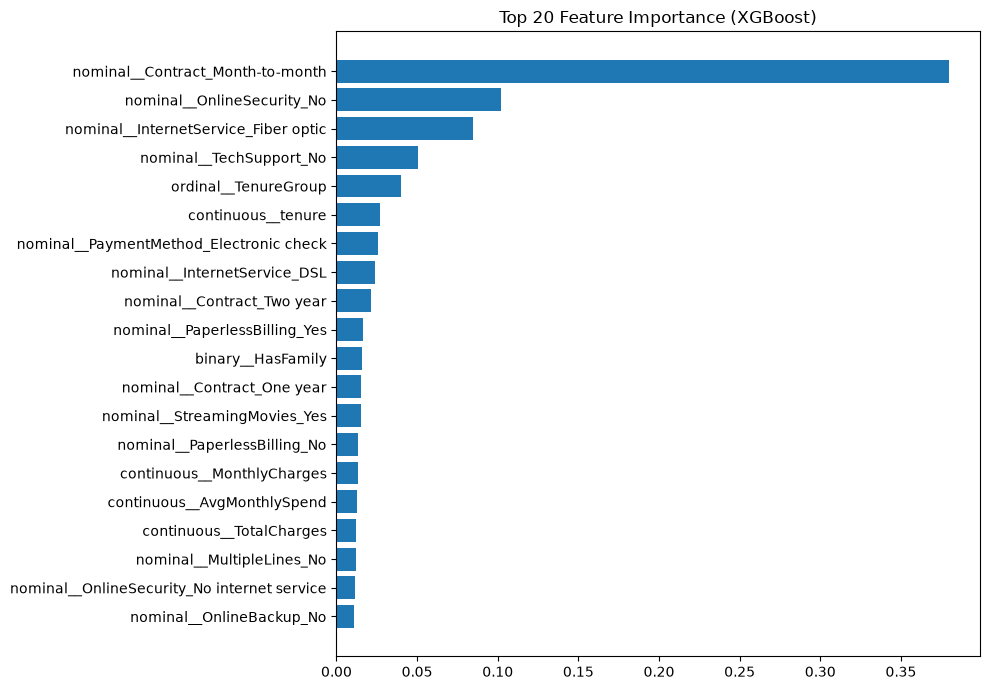

In [27]:
top20 = importance.head(20)

plt.figure(figsize=(10,7))

plt.barh(
    top20["Feature"],
    top20["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Top 20 Feature Importance (XGBoost)")

plt.tight_layout()

plt.show()

## Model Comparison

The XGBoost model is compared with the previously developed models.

The comparison includes:

- Logistic Regression
- Decision Tree
- Random Forest
- XGBoost

The objective is to identify the model that best satisfies the customer churn prediction problem.

In [28]:
comparison = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC"
    ],

    "Logistic Regression":[
        0.8010,
        0.6442,
        0.5615,
        0.6000,
        0.8350
    ],

    "Decision Tree":[
        0.7839,
        0.5862,
        0.6364,
        0.6103,
        0.8221
    ],

    "Random Forest":[
        0.7932,
        0.6436,
        0.4973,
        0.5611,
        0.8340
    ],

    "XGBoost": test_summary["Score"]

})

comparison

,Metric,Logistic Regression,Decision Tree,Random Forest,XGBoost
0,Accuracy,0.8010,0.7839,0.7932,0.7967
1,Precision,0.6442,0.5862,0.6436,0.6477
2,Recall,0.5615,0.6364,0.4973,0.5160
3,F1,0.6000,0.6103,0.5611,0.5744
4,ROC-AUC,0.8350,0.8221,0.8340,0.8411


## Save Model

The trained XGBoost pipeline is serialized using Joblib.

Saving the complete pipeline ensures that preprocessing and prediction remain identical during deployment.

In [30]:
joblib.dump(
    best_pipeline,
    "../models/xgboost_pipeline.pkl"
)

print("XGBoost model saved successfully.")

XGBoost model saved successfully.


# Notebook Summary

## Model Developed

- XGBoost Classifier

## Key Achievements

- Built a complete XGBoost classification pipeline.
- Applied feature preprocessing using a ColumnTransformer.
- Evaluated the model using 5-fold Stratified Cross Validation.
- Performed hyperparameter tuning with GridSearchCV.
- Evaluated the tuned model on an unseen test dataset.
- Analyzed feature importance to identify key business drivers.
- Compared XGBoost with Logistic Regression, Decision Tree, and Random Forest models.
- Saved the complete prediction pipeline for future deployment.

## Business Conclusion

XGBoost combines high predictive accuracy with strong generalization capability by sequentially correcting the errors made by previous trees.

It is widely regarded as one of the most effective algorithms for structured tabular datasets and serves as a strong candidate for customer churn prediction.

## Next Steps

The next notebook will implement the CatBoost classifier and compare its performance with all previously developed machine learning models.

In [31]:
cv_summary.to_csv(
    "../reports/xgboost_cv.csv",
    index=False
)